In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from scipy.stats import chi2_contingency
from sklearn.dummy import DummyClassifier

# 1. Dummy Classifier

In [3]:
data = pd.read_csv("../data/kaggle_b2_fraud_train_v3.csv")

df = data.copy()

In [4]:
df

,customer_id,account_id,age,tenure_months,annual_income_eur,credit_score,num_transactions_30d,avg_amount_30d_eur,max_amount_30d_eur,days_since_last_login,...,internal_signal_5,internal_signal_6,internal_signal_7,internal_signal_8,terms_accepted_flag,partner_risk_indicator,manual_review_result,post_event_status_code,chargeback_resolution_time_days,legacy_partner_score
0,CUST_6O9Q8D4I36,ACC_TXXXTNEUVKFY,34,108,38635.01,544.0,20,60.92,80.16,4.9,...,0.39006,0.10963,0.55097,-0.56104,1,NaN,approve,0,7.9,NaN
1,CUST_FGUGTW230C,ACC_70VD7A4FFWCW,48,2,19912.97,703.0,21,112.11,571.12,0.3,...,0.03265,-0.40256,0.36218,0.86583,1,NaN,approve,0,5.5,NaN
2,CUST_8ZI3LCBZ0W,ACC_AF53381QSC0L,27,0,20326.87,720.0,25,73.61,492.57,4.6,...,-0.15637,0.57818,0.28902,-2.19864,1,NaN,approve,0,7.2,NaN
3,CUST_5MP3AR41CJ,ACC_U7WZGJ486LIV,45,49,38452.47,703.0,17,47.53,204.18,25.3,...,-1.02145,0.63908,-0.89190,-0.81592,1,NaN,approve,0,4.4,NaN
4,CUST_GNPL83JB0J,ACC_XW7DS3ED5J4Y,37,46,NaN,594.0,13,99.95,734.09,12.8,...,-0.65771,0.08020,0.17606,0.86739,1,NaN,approve,0,4.9,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159995,CUST_I81IW5SVRQ,ACC_UPDTFTYTSM0A,56,0,34775.62,727.0,21,51.72,226.11,3.8,...,-2.54086,-0.60747,0.23252,-0.06215,1,-1.535486,approve,0,1.0,NaN
159996,CUST_QT6DDEMKTJ,ACC_97NE0LBL5W9U,41,4,88617.57,770.0,18,NaN,171.07,15.1,...,0.34098,-1.78817,0.31788,0.51072,1,NaN,approve,0,7.4,NaN
159997,CUST_I0JS1GTS98,ACC_9JJ84W64Z7GX,30,2,41148.54,738.0,20,29.34,119.81,0.7,...,-1.28947,-0.32324,-0.06238,-0.99076,1,NaN,approve,3,6.6,NaN
159998,CUST_L7GUCJ3TFY,ACC_NGFXDR7HW1ZS,56,6,NaN,719.0,25,88.56,553.16,22.6,...,0.47179,-0.22090,-1.34239,-0.30513,1,NaN,approve,0,12.5,NaN


In [5]:
X = df.drop(columns="target_is_fraud") # J'ai choisis la colonne target_is_fraud en target
y = df["target_is_fraud"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=42)

In [7]:
baseline = DummyClassifier()

In [8]:
baseline.fit(X_train, y_train)
y_pred = baseline.predict(X_test)

In [9]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.96875
Confusion Matrix:
 [[38750     0]
 [ 1250     0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98     38750
           1       0.00      0.00      0.00      1250

    accuracy                           0.97     40000
   macro avg       0.48      0.50      0.49     40000
weighted avg       0.94      0.97      0.95     40000



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

In [10]:
df_test = pd.read_csv("../data/kaggle_b2_fraud_test_v3.csv")
df_test

,customer_id,account_id,age,tenure_months,annual_income_eur,credit_score,num_transactions_30d,avg_amount_30d_eur,max_amount_30d_eur,days_since_last_login,...,internal_signal_5,internal_signal_6,internal_signal_7,internal_signal_8,terms_accepted_flag,partner_risk_indicator,manual_review_result,post_event_status_code,chargeback_resolution_time_days,legacy_partner_score
0,CUST_E5RX1BC9II,ACC_YFJ1HGWZBXY7,43,53,25587.55,639.0,24,106.61,781.55,7.3,...,-1.32827,-0.67095,0.96425,0.13556,1,NaN,approve,0,9.0,NaN
1,CUST_BHWIUKERGN,ACC_3GPLTB4O5TQR,22,5,45378.40,699.0,21,54.17,252.95,4.2,...,0.38501,0.98914,1.56030,1.05211,1,NaN,review,0,8.8,NaN
2,CUST_EXT9NA4CHU,ACC_BJV525XTFPU4,42,2,36643.70,765.0,17,44.40,238.79,7.0,...,-1.02340,-1.15396,-0.33549,-0.15284,1,NaN,approve,0,5.3,NaN
3,CUST_9FSJE5R1NY,ACC_3R73734P68KY,39,20,30283.30,573.0,29,38.30,321.44,28.3,...,0.86966,0.47447,0.41196,0.23284,1,NaN,review,2,0.5,NaN
4,CUST_GDQXMODBED,ACC_OACZ35SKXJOU,54,10,35294.22,624.0,21,70.93,540.48,21.7,...,-0.05352,-0.02331,-0.22379,-0.88609,1,NaN,approve,4,13.8,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,CUST_1OM9UCID91,ACC_LKZHMRZ96RKC,44,3,41531.58,622.0,24,42.99,214.60,7.3,...,0.00140,2.30414,-0.55719,1.37723,1,-0.4551,approve,0,8.1,NaN
39996,CUST_VDEY72BIZP,ACC_LS8VIDTNSLVW,48,12,36783.80,697.0,25,21.17,69.19,3.8,...,-0.00073,1.45201,-0.08652,-0.98155,1,NaN,approve,0,5.4,NaN
39997,CUST_UQEZ9KKIFG,ACC_4QLK8U7F3ZCS,49,28,55963.60,658.0,18,180.58,410.17,3.6,...,0.15541,-0.74079,1.37543,1.14303,1,NaN,approve,0,16.7,NaN
39998,CUST_IXX0BE9VQD,ACC_7Y9LSXFR8WS8,31,7,9638.61,683.0,19,129.93,643.13,13.9,...,3.02645,-0.63311,-0.00841,1.52853,1,NaN,review,4,1.6,NaN


In [11]:
X_test_final = df_test[X_train.columns]

In [12]:
y_pred_test = baseline.predict(X_test_final)


In [13]:
y_pred_test

array([0, 0, 0, ..., 0, 0, 0])

In [14]:
df_results = pd.DataFrame({
    "customer_id": df_test["customer_id"],  
    "target_is_fraud": y_pred_test          
})

print(df_results.head())

df_results.to_csv("../Preds/Baseline_preds_Noah.csv", index=False)

       customer_id  target_is_fraud
0  CUST_E5RX1BC9II                0
1  CUST_BHWIUKERGN                0
2  CUST_EXT9NA4CHU                0
3  CUST_9FSJE5R1NY                0
4  CUST_GDQXMODBED                0


In [15]:
df_results.drop_duplicates().sum()

customer_id        CUST_E5RX1BC9IICUST_BHWIUKERGNCUST_EXT9NA4CHUC...
target_is_fraud                                                    0
dtype: object

# 1. Exploratory Data Analysis

## Objectif :
- Comprendre du mieux possible nos données (un petit pas en avant vaut mieux qu'un grand pas en arriere)
- Développer une premiere stratégie de modélisation 

## Checklist de base
#### Analyse de Forme :
- **variable target** : target_is_fraud
- **lignes et colonnes** : 160000 , 56
- **types de variables** : qualitatives : 23, quantitatives : 33
- **Analyse des valeurs manquantes** :
    - peu de NaN (3 des variables > 90% de NaN)

#### Analyse de Fond :
- **Visualisation de la target** :
    - 3% de positifs (4924 / 160000)
    
    
    
- **Signification des variables** :
    -  variables continues standardisées, skewed (asymétriques), 
    - age  : On remarque qu'une partie des âge sont négatif, donc se pencher là dessus, sinon répartition logique
    - variable qualitative : indications non-binaire sur les infirmations des différentes colonnes



#### Observation :

- **Variables intéressantes** :
    - is_vpn & is_new_device sont intéressantes 

- **Variables à enlever** :
    - chargebacks_12m
    - post_event_status_code


    

### Analyse de la forme des données

In [16]:
df.shape

(160000, 56)

In [17]:
df.dtypes.value_counts()

float64    23
object     20
int64      13
Name: count, dtype: int64

<Axes: >

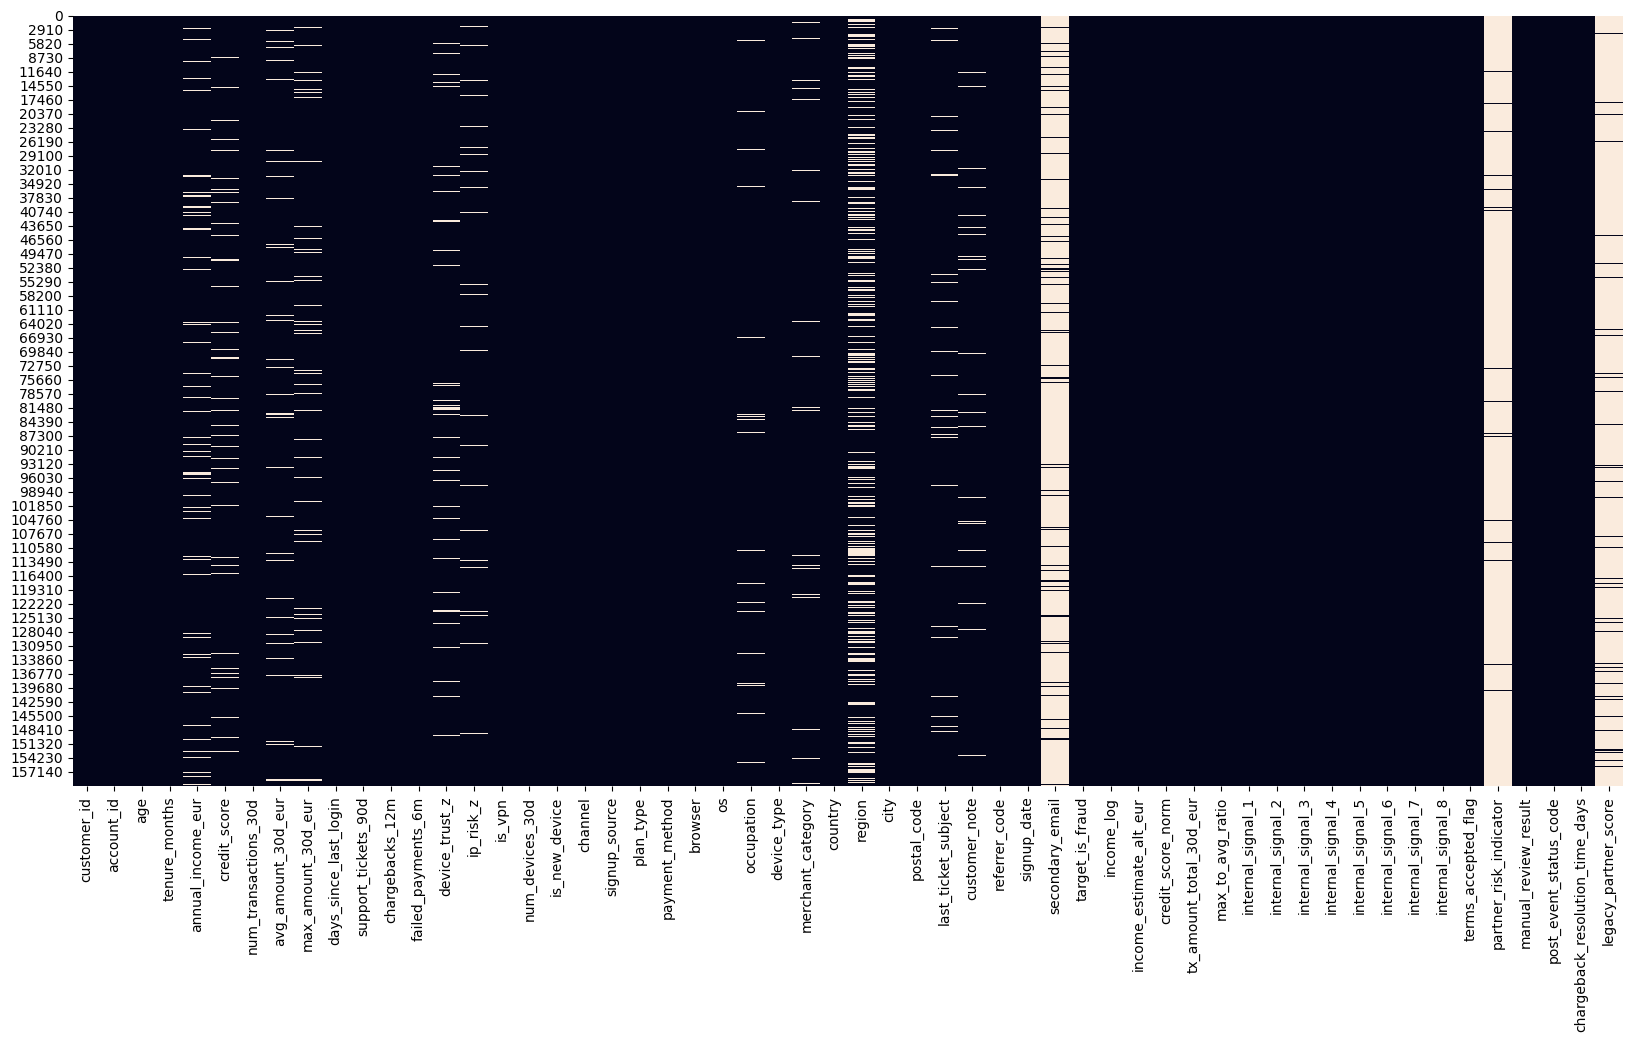

In [18]:
plt.figure(figsize=(20,10))
sns.heatmap(df.isna(), cbar=False)

In [19]:
(df.isna().sum()/df.shape[0]).sort_values(ascending=True)

customer_id                        0.000000
city                               0.000000
postal_code                        0.000000
referrer_code                      0.000000
signup_date                        0.000000
target_is_fraud                    0.000000
income_log                         0.000000
income_estimate_alt_eur            0.000000
credit_score_norm                  0.000000
tx_amount_total_30d_eur            0.000000
max_to_avg_ratio                   0.000000
internal_signal_1                  0.000000
internal_signal_2                  0.000000
internal_signal_3                  0.000000
internal_signal_4                  0.000000
internal_signal_5                  0.000000
internal_signal_6                  0.000000
internal_signal_7                  0.000000
internal_signal_8                  0.000000
terms_accepted_flag                0.000000
manual_review_result               0.000000
post_event_status_code             0.000000
chargeback_resolution_time_days 

## Analyse du Fond
### 1. Visulation initiale - Elimination des colonnes inutiles

In [20]:
df = df[df.columns[df.isna().sum()/df.shape[0] <0.9]]
df.head()

,customer_id,account_id,age,tenure_months,annual_income_eur,credit_score,num_transactions_30d,avg_amount_30d_eur,max_amount_30d_eur,days_since_last_login,...,internal_signal_3,internal_signal_4,internal_signal_5,internal_signal_6,internal_signal_7,internal_signal_8,terms_accepted_flag,manual_review_result,post_event_status_code,chargeback_resolution_time_days
0,CUST_6O9Q8D4I36,ACC_TXXXTNEUVKFY,34,108,38635.01,544.0,20,60.92,80.16,4.9,...,-0.68676,-1.54627,0.39006,0.10963,0.55097,-0.56104,1,approve,0,7.9
1,CUST_FGUGTW230C,ACC_70VD7A4FFWCW,48,2,19912.97,703.0,21,112.11,571.12,0.3,...,-0.17429,-0.00054,0.03265,-0.40256,0.36218,0.86583,1,approve,0,5.5
2,CUST_8ZI3LCBZ0W,ACC_AF53381QSC0L,27,0,20326.87,720.0,25,73.61,492.57,4.6,...,-0.86064,-0.32183,-0.15637,0.57818,0.28902,-2.19864,1,approve,0,7.2
3,CUST_5MP3AR41CJ,ACC_U7WZGJ486LIV,45,49,38452.47,703.0,17,47.53,204.18,25.3,...,-1.11761,1.35968,-1.02145,0.63908,-0.89190,-0.81592,1,approve,0,4.4
4,CUST_GNPL83JB0J,ACC_XW7DS3ED5J4Y,37,46,NaN,594.0,13,99.95,734.09,12.8,...,0.11581,1.65795,-0.65771,0.08020,0.17606,0.86739,1,approve,0,4.9


<Axes: >

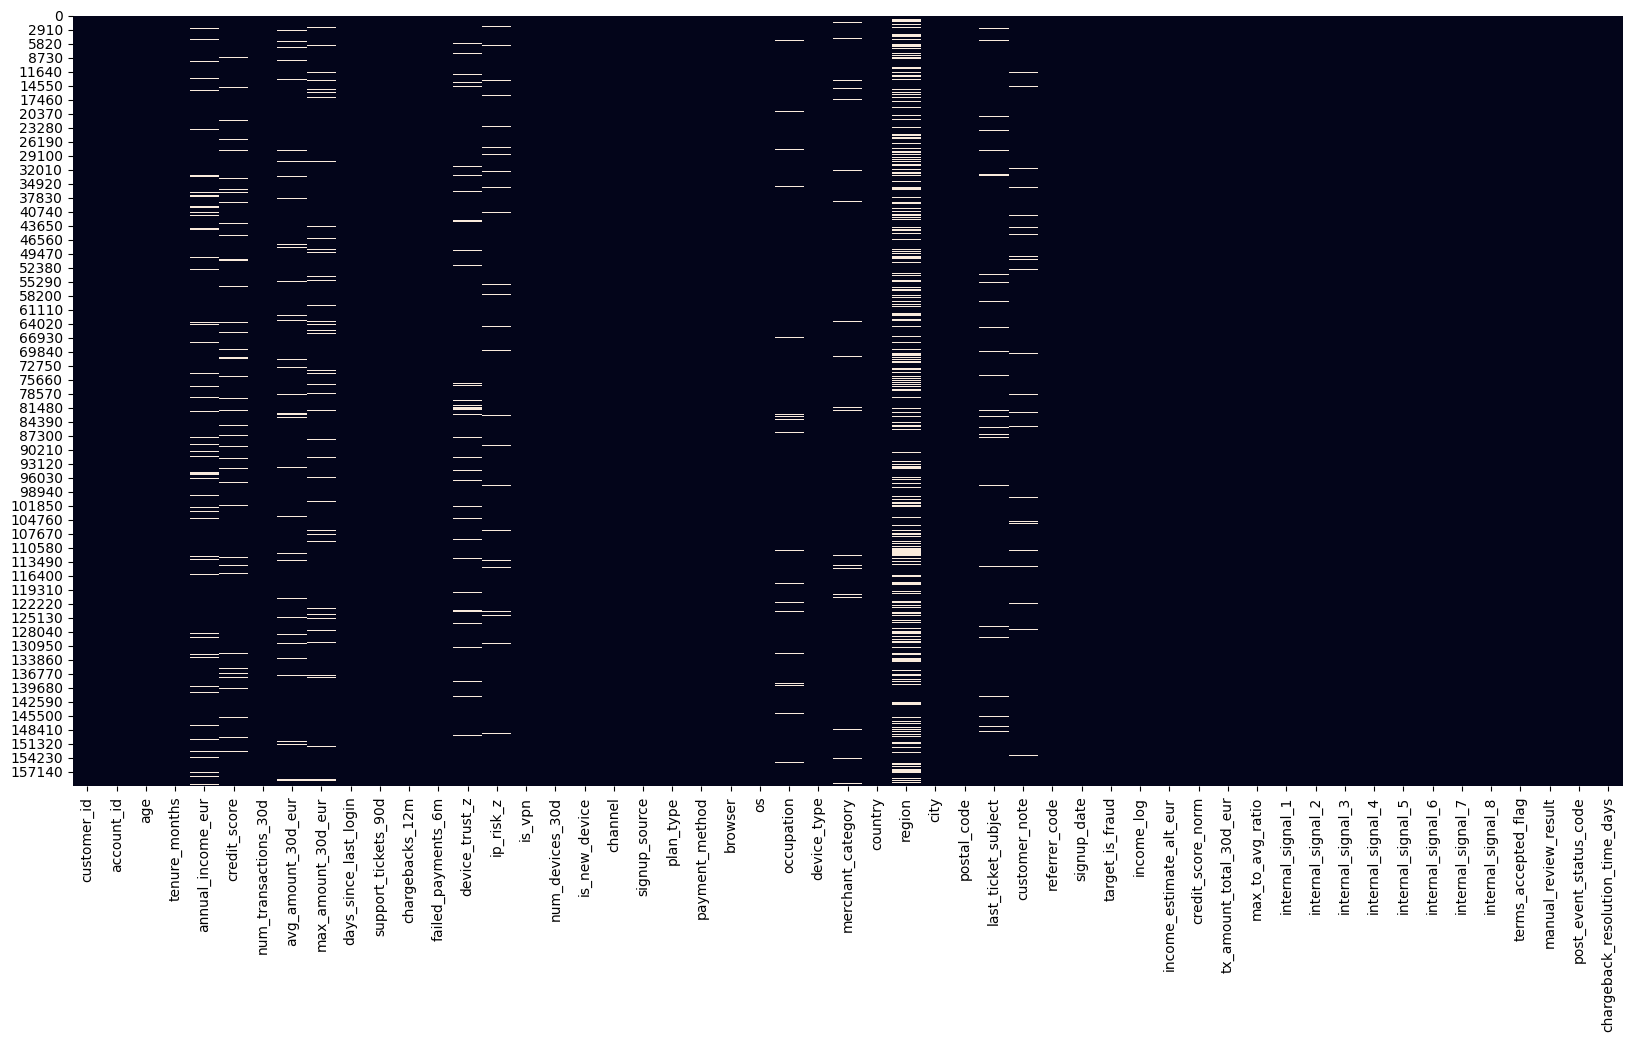

In [21]:
plt.figure(figsize=(20,10))
sns.heatmap(df.isna(), cbar=False)

### Examen de la colonne target


In [22]:
df['target_is_fraud'].value_counts(normalize=True)

target_is_fraud
0    0.969225
1    0.030775
Name: proportion, dtype: float64

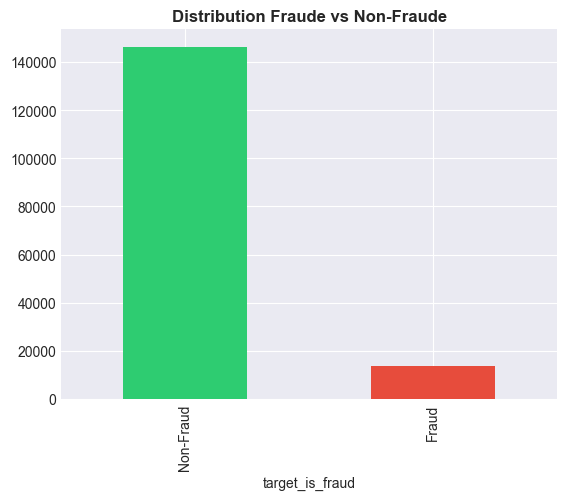

In [8]:
fig = plt.figure()
df['target_is_fraud'].value_counts().plot(kind='bar', color=['#2ecc71', '#e74c3c'])
plt.title('Distribution Fraude vs Non-Fraude', fontweight='bold')
plt.xticks([0,1], ['Non-Fraud', 'Fraud'])
plt.show()

### histogrames des variables continues 

/var/folders/ff/6dq6sfws2k1899t9k3qzw9sc0000gn/T/ipykernel_58479/2417630899.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col])
/var/folders/ff/6dq6sfws2k1899t9k3qzw9sc0000gn/T/ipykernel_58479/2417630899.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col])
/var/folders/ff/6dq6sf

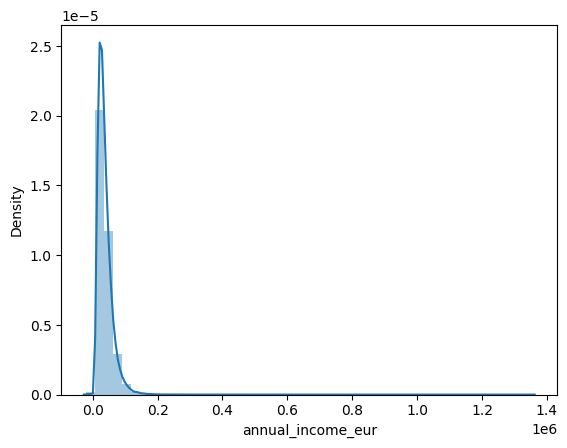

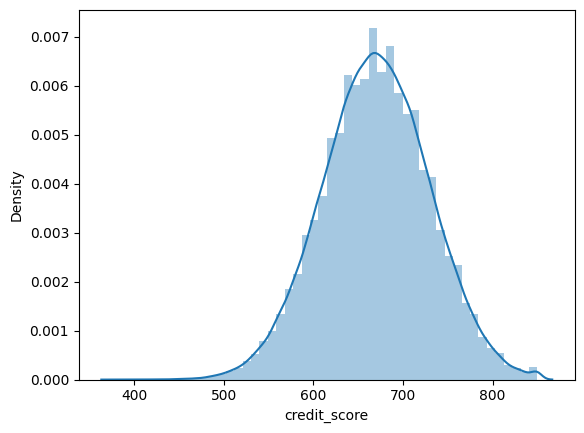

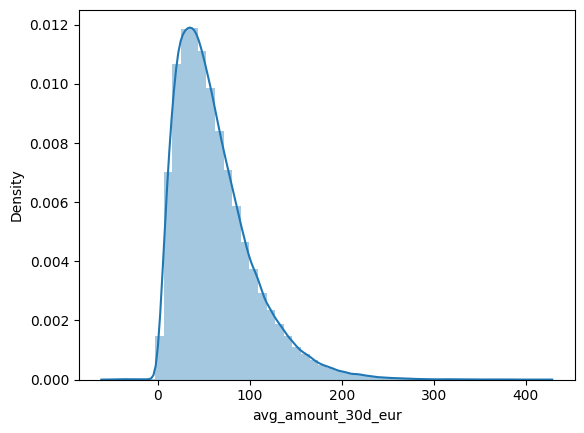

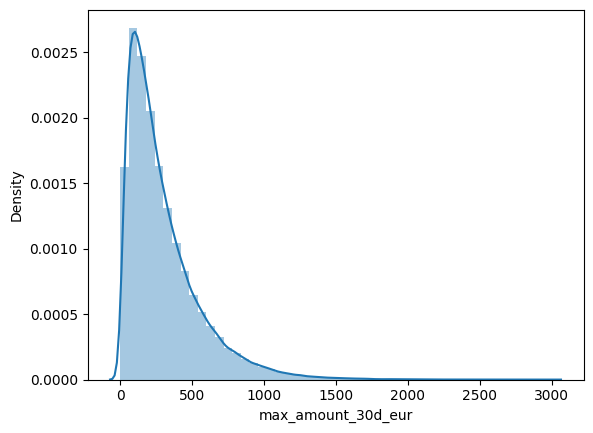

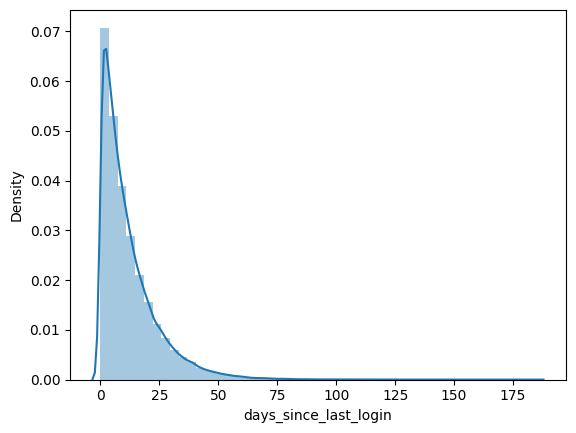

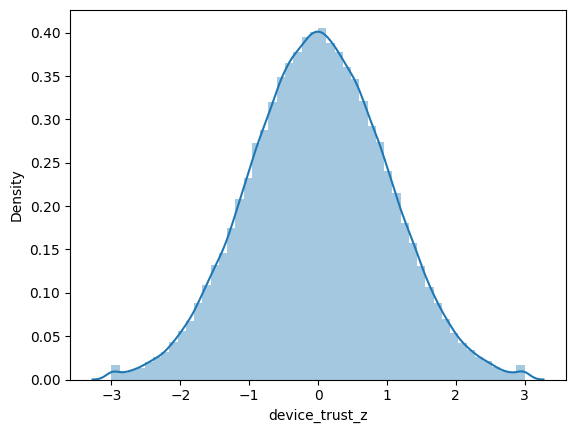

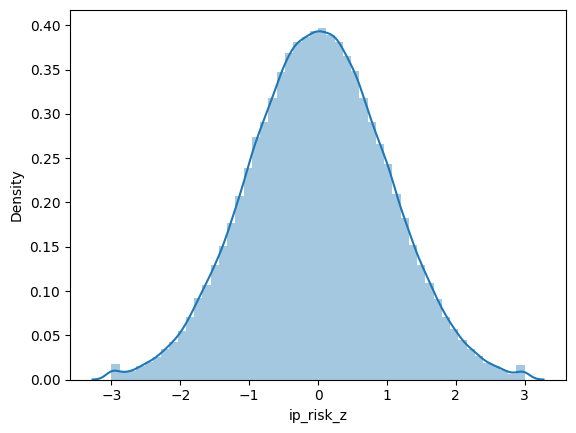

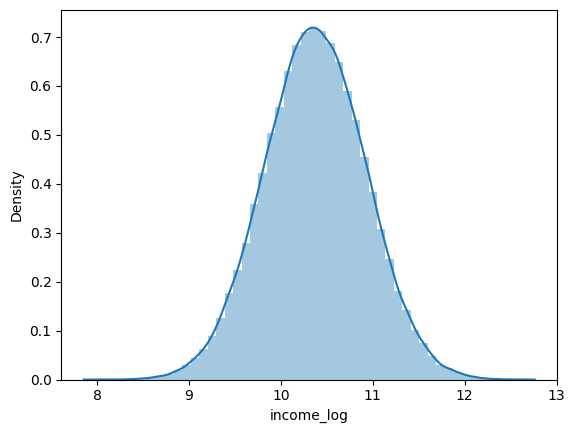

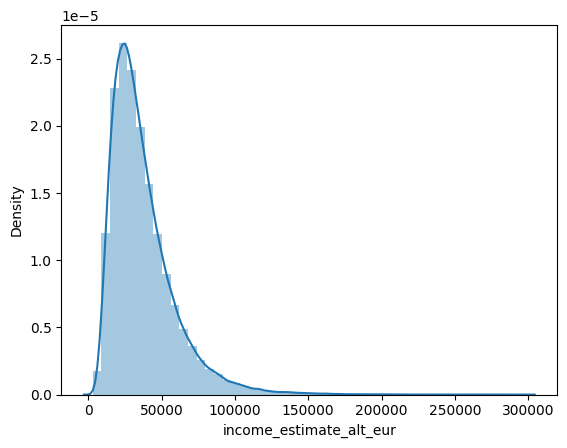

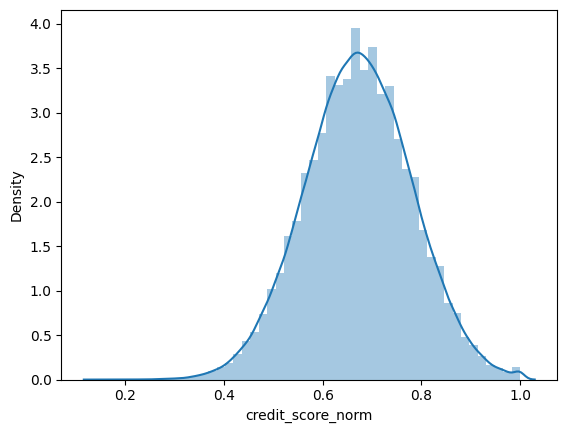

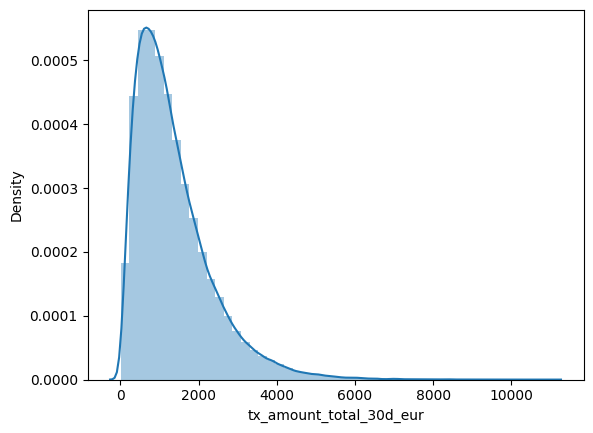

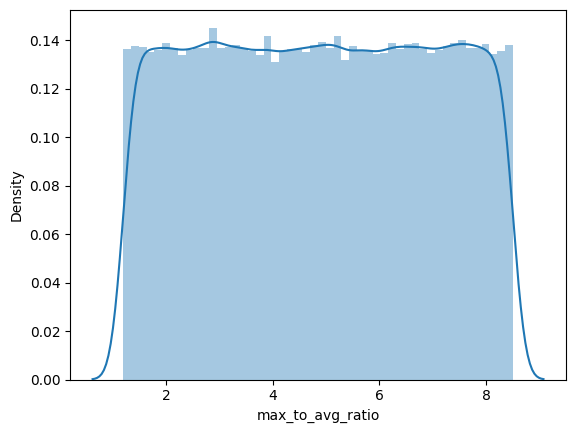

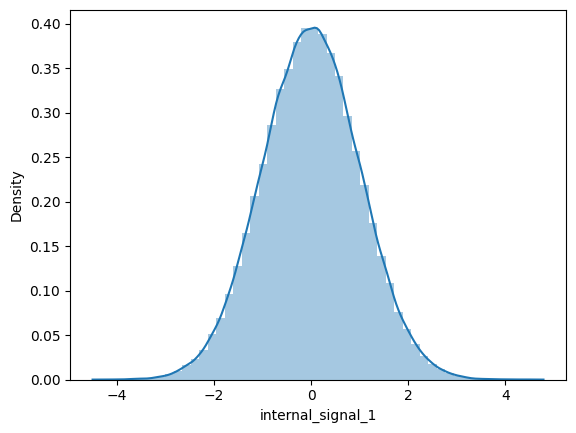

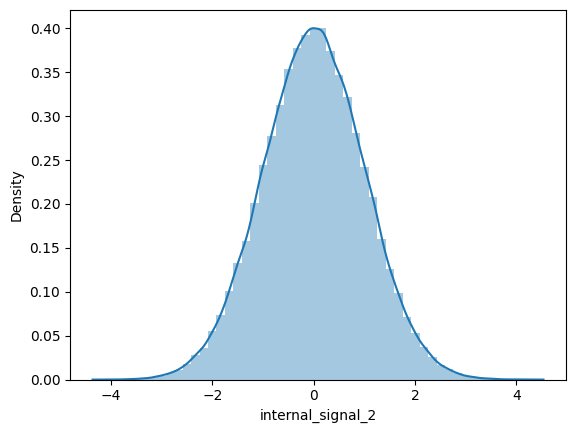

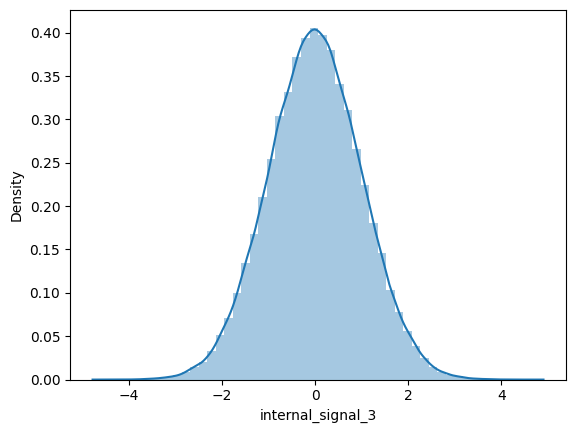

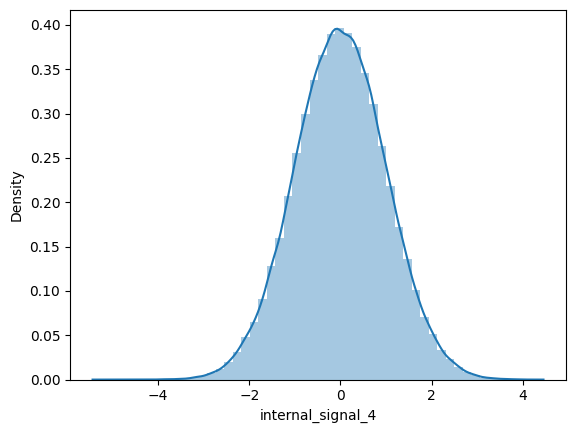

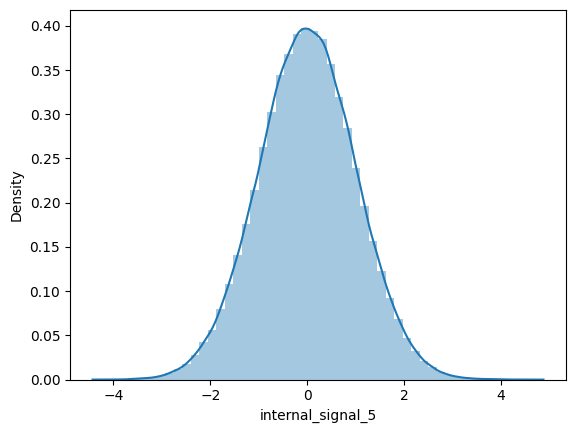

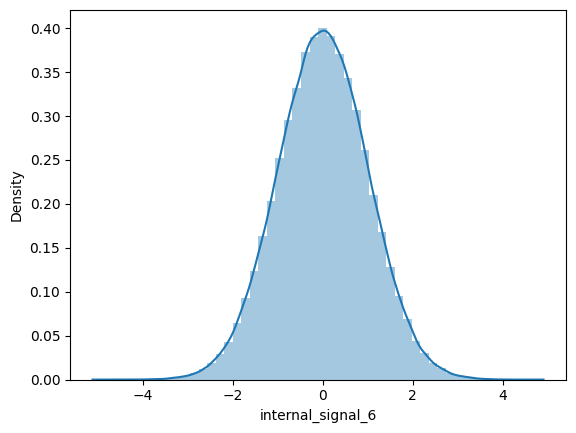

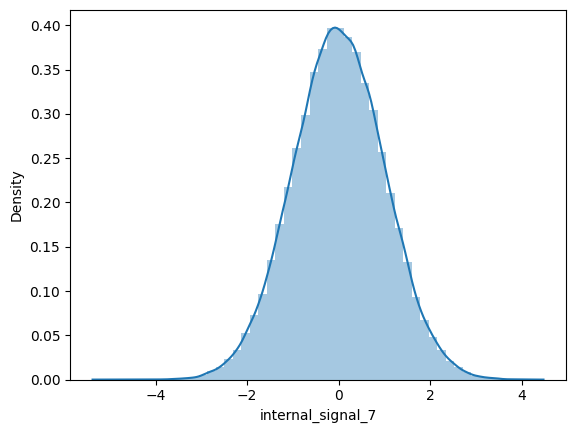

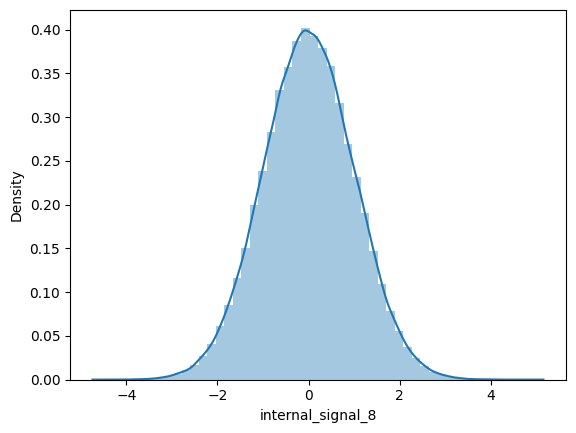

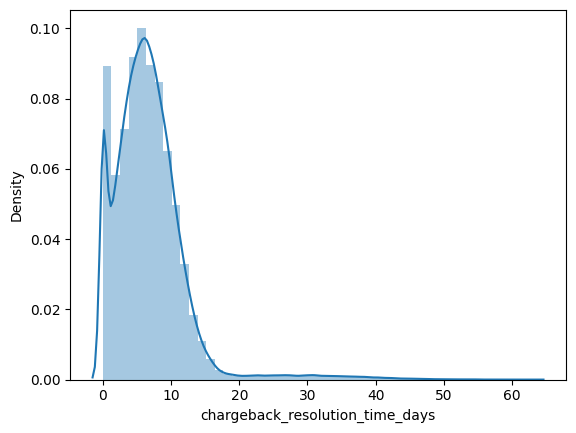

In [23]:
for col in df.select_dtypes('float'):
    plt.figure()
    sns.distplot(df[col])

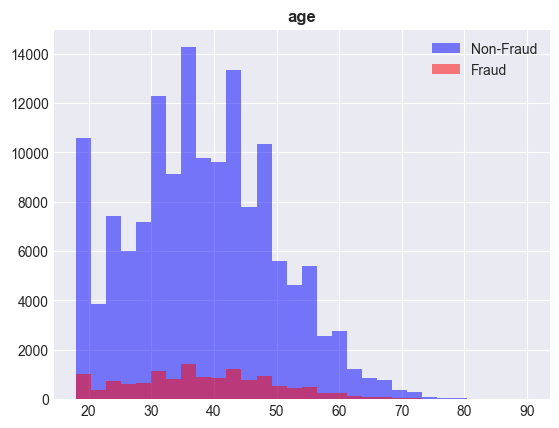

<Figure size 640x480 with 0 Axes>

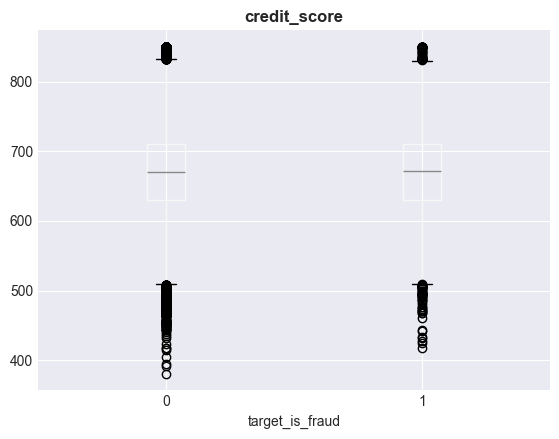

<Figure size 640x480 with 0 Axes>

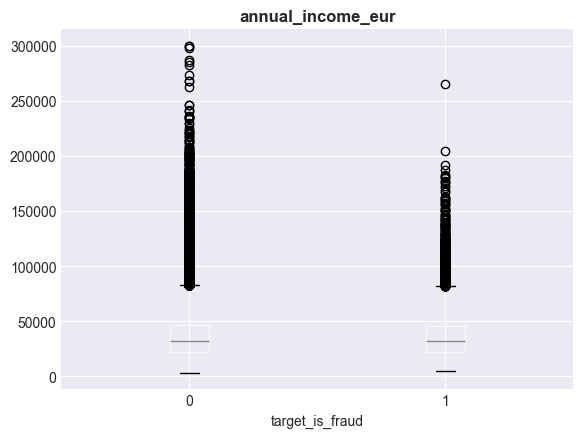

<Figure size 640x480 with 0 Axes>

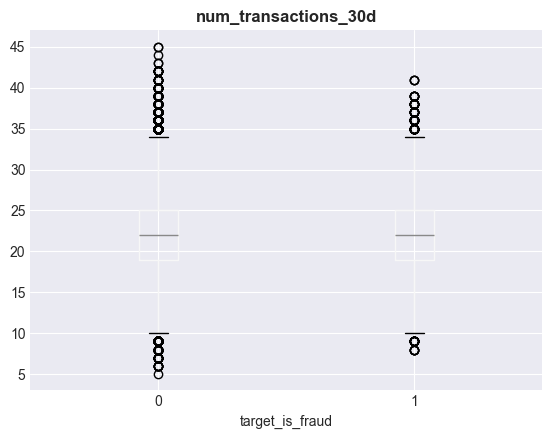

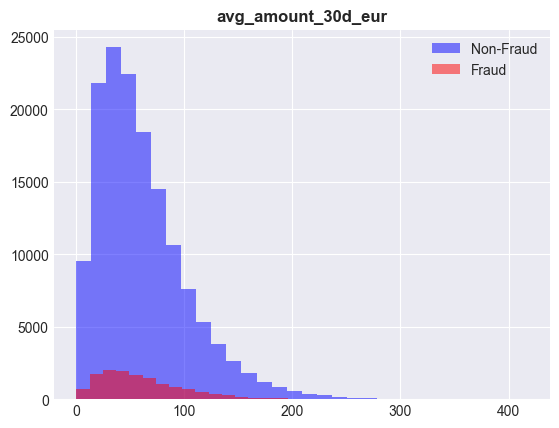

<Figure size 640x480 with 0 Axes>

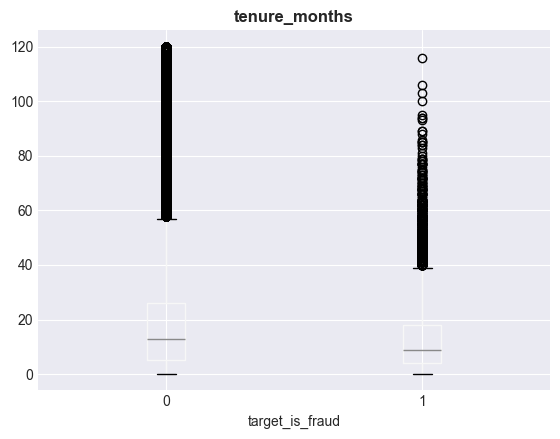

<Figure size 640x480 with 0 Axes>

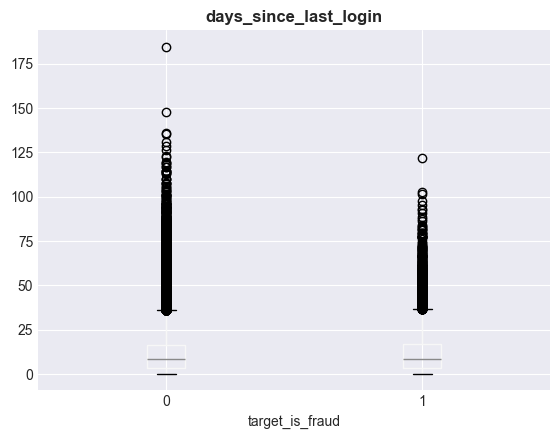

<Figure size 640x480 with 0 Axes>

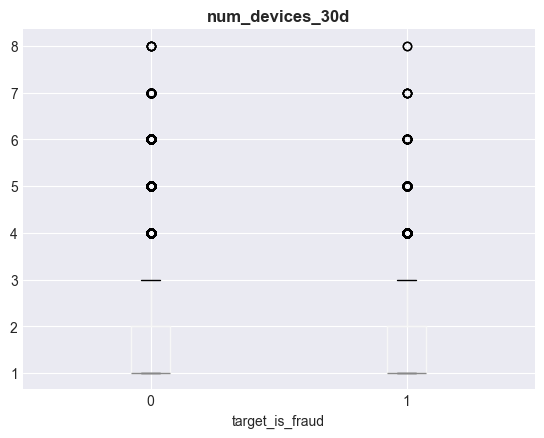

In [9]:
numeric_features = ['age', 'credit_score', 'annual_income_eur', 'num_transactions_30d',
                    'avg_amount_30d_eur', 'tenure_months', 'days_since_last_login', 'num_devices_30d']

for col in numeric_features:
    if col in df.columns:
        fig = plt.figure()
        if col in ['age', 'avg_amount_30d_eur']:
            df[df['target_is_fraud']==0][col].hist(alpha=0.5, bins=30, label='Non-Fraud', color='blue')
            df[df['target_is_fraud']==1][col].hist(alpha=0.5, bins=30, label='Fraud', color='red')
            plt.legend()
        else:
            df.boxplot(column=col, by='target_is_fraud')
            plt.suptitle('')
        plt.title(col, fontweight='bold')
        plt.show()

In [25]:
df['age'].value_counts()

age
18     8402
38     5385
37     5278
39     5235
36     5230
       ... 
108       1
103       1
131       1
88        1
130       1
Name: count, Length: 131, dtype: int64

### Variables Qualitatives

In [26]:
for col in df.select_dtypes('object'):
    print(f'{col :-<50} {df[col].unique()}')

customer_id--------------------------------------- ['CUST_6O9Q8D4I36' 'CUST_FGUGTW230C' 'CUST_8ZI3LCBZ0W' ...
 'CUST_I0JS1GTS98' 'CUST_L7GUCJ3TFY' 'CUST_8IJJ8XKNM9']
account_id---------------------------------------- ['ACC_TXXXTNEUVKFY' 'ACC_70VD7A4FFWCW' 'ACC_AF53381QSC0L' ...
 'ACC_9JJ84W64Z7GX' 'ACC_NGFXDR7HW1ZS' 'ACC_CBGP5O5DCOWR']
channel------------------------------------------- ['mobile_app' 'web' 'partner_api' 'call_center']
signup_source------------------------------------- ['ads_social' 'referral' 'organic' 'ads_search' 'affiliate'
 'email_campaign']
plan_type----------------------------------------- ['basic' 'standard' 'premium' 'enterprise']
payment_method------------------------------------ ['card' 'google_pay' 'paypal' 'sepa' 'crypto' 'apple_pay' 'ApplePay'
 'pay pal' 'SEPA ' 'googlepay']
browser------------------------------------------- ['Chrome' 'Firefox' 'Safari' 'Edge' 'Opera' 'Other']
os------------------------------------------------ ['Android' 'macOS' 'Windows' '

## Relation Target / Variables
### Création de sous-ensembles positifs et négatifs

In [29]:
positive_df = df[df['target_is_fraud'] == 1]

In [30]:
negative_df = df[df['target_is_fraud'] == 0]

In [31]:
positive_df

,customer_id,account_id,age,tenure_months,annual_income_eur,credit_score,num_transactions_30d,avg_amount_30d_eur,max_amount_30d_eur,days_since_last_login,...,internal_signal_3,internal_signal_4,internal_signal_5,internal_signal_6,internal_signal_7,internal_signal_8,terms_accepted_flag,manual_review_result,post_event_status_code,chargeback_resolution_time_days
50,CUST_OEMG27COP4,ACC_RXUEF30KHH08,47,1,19290.97,630.0,18,NaN,633.59,13.8,...,1.12458,-1.57298,0.14368,0.07842,1.37434,-0.05517,1,block,4,44.3
99,CUST_ENS85M8ED0,ACC_ID62FI9UP6PN,43,4,NaN,668.0,24,86.56,352.69,6.4,...,1.24346,1.96101,0.84405,0.36443,-1.35928,0.69614,1,block,4,38.1
145,CUST_INAHX2LBEZ,ACC_5O2BD3P8UI6M,43,3,12665.88,723.0,26,34.09,125.89,0.4,...,-1.76907,1.46294,0.05271,-0.11622,0.25762,-0.03367,1,block,4,18.6
174,CUST_BP6NUOEUR1,ACC_G6LU8LMH2CK8,43,57,NaN,631.0,22,102.20,703.37,15.4,...,0.65285,0.34477,-0.03304,-0.08778,0.33462,-1.49611,1,review,3,42.3
213,CUST_Q3CJLADUO2,ACC_B155C1ZQND9A,38,6,25921.12,669.0,15,28.65,243.30,1.3,...,-0.23947,0.77559,-0.63848,-0.11214,0.43820,0.43627,1,block,3,31.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159857,CUST_KBGLGPI4UH,ACC_YSZA8W0F2EE4,40,58,25245.18,654.0,21,87.91,618.45,26.9,...,-2.03062,0.26807,1.05336,-0.05448,0.34202,-0.14056,1,review,4,33.2
159889,CUST_LP011VQ0RO,ACC_6UTA5Q7MH5BM,52,9,NaN,722.0,21,85.94,NaN,14.5,...,-0.11336,-0.48084,-0.82657,-0.93020,-0.26794,2.63436,1,block,3,26.6
159931,CUST_JK01LW393C,ACC_LXLIJTG4LRM7,18,19,16920.95,640.0,22,48.41,153.34,1.7,...,-0.21230,0.19613,1.09624,-0.14489,-0.58646,-0.26749,1,review,3,25.1
159953,CUST_QU5BGNOUPA,ACC_Y3TYFDEGDKN0,49,6,37729.57,638.0,28,69.94,204.98,18.5,...,0.58202,0.82979,1.00926,-3.50369,-0.49770,1.45163,1,block,4,43.3


### Relation Target / age

<Axes: xlabel='age', ylabel='count'>

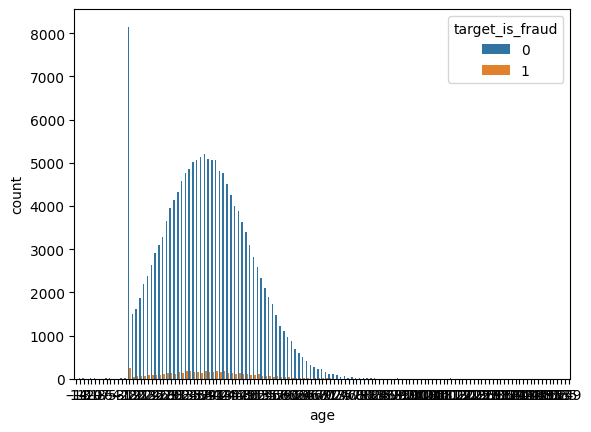

In [32]:
sns.countplot(x='age', hue='target_is_fraud', data=df)

### Relation Target / moyen de paiement

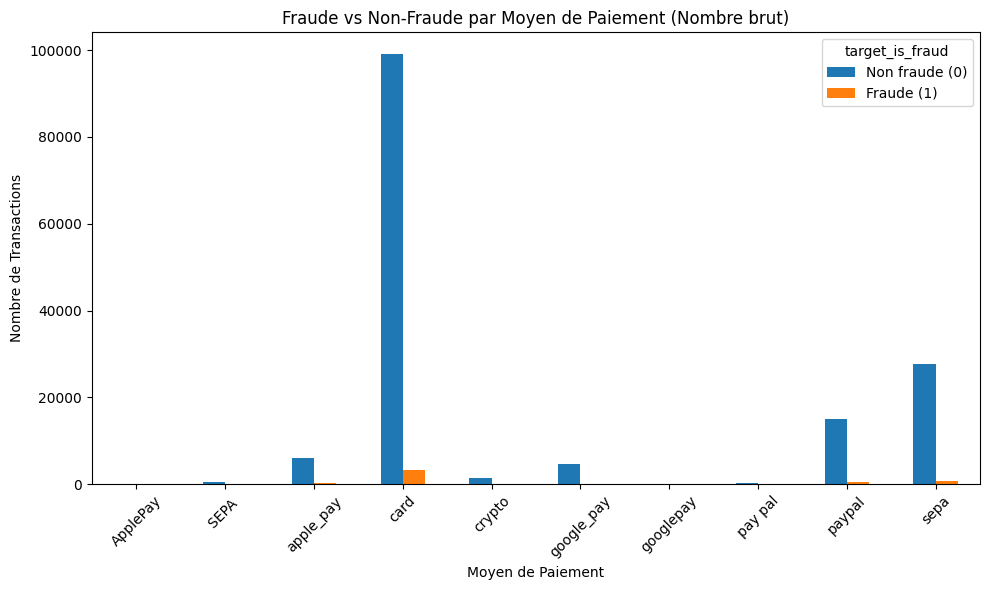

In [35]:
counts = df.groupby(['payment_method', 'target_is_fraud']).size().unstack(fill_value=0)

# Plot
counts.plot(kind='bar', figsize=(10,6))

plt.title("Fraude vs Non-Fraude par Moyen de Paiement (Nombre brut)")
plt.xlabel("Moyen de Paiement")
plt.ylabel("Nombre de Transactions")
plt.xticks(rotation=45)
plt.legend(title="target_is_fraud", labels=["Non fraude (0)", "Fraude (1)"])
plt.tight_layout()
plt.show()

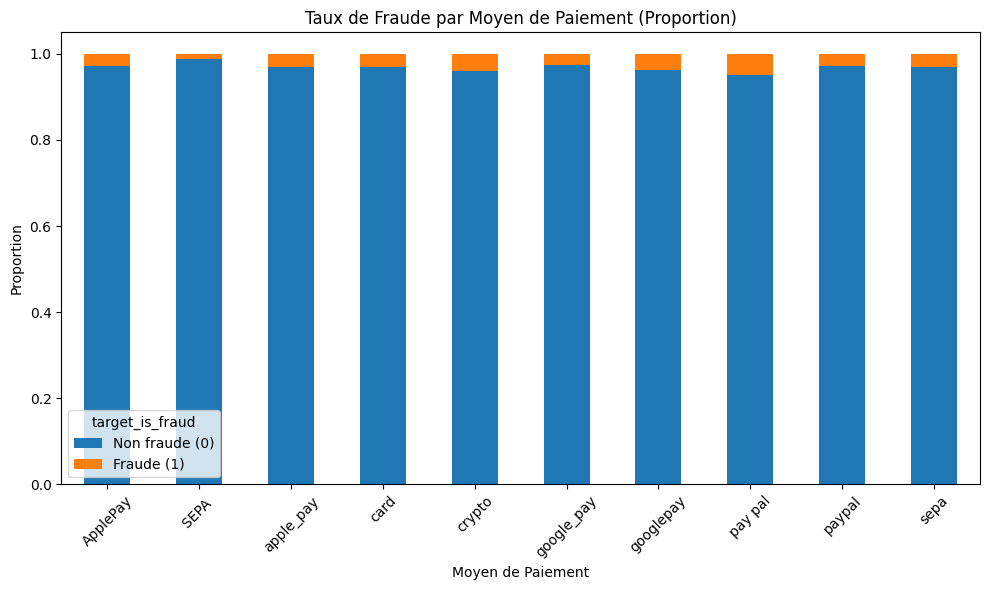

In [36]:
proportions = counts.div(counts.sum(axis=1), axis=0)

# Plot
proportions.plot(kind='bar', stacked=True, figsize=(10,6))

plt.title("Taux de Fraude par Moyen de Paiement (Proportion)")
plt.xlabel("Moyen de Paiement")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.legend(title="target_is_fraud", labels=["Non fraude (0)", "Fraude (1)"])
plt.tight_layout()
plt.show()

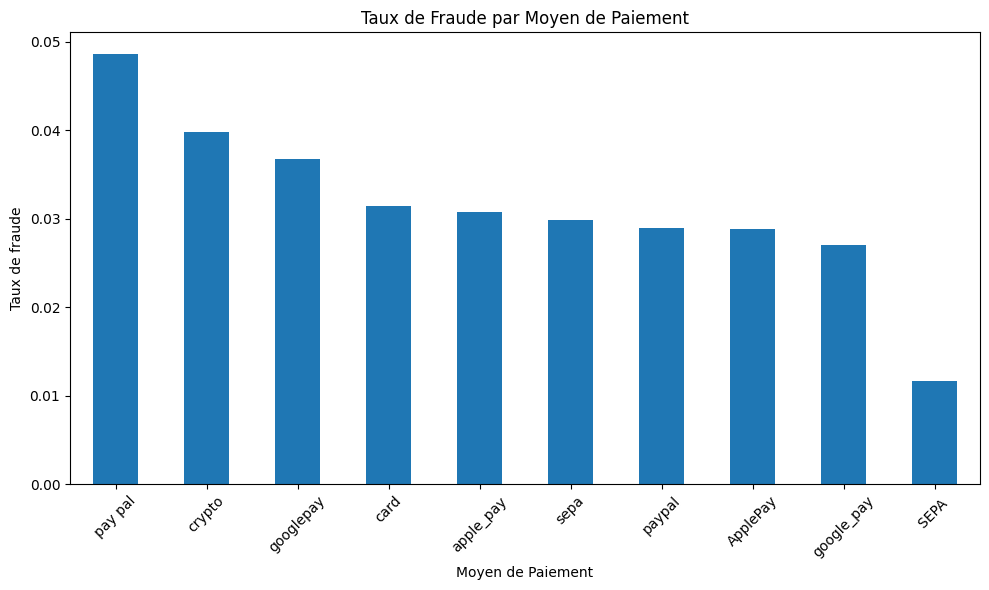

In [37]:
fraud_rate = df.groupby('payment_method')['target_is_fraud'].mean().sort_values(ascending=False)

fraud_rate.plot(kind='bar', figsize=(10,6))

plt.title("Taux de Fraude par Moyen de Paiement")
plt.xlabel("Moyen de Paiement")
plt.ylabel("Taux de fraude")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Interprétation

- **0** → aucune relation  
- **0.1 – 0.2** → faible  
- **0.2 – 0.4** → modérée  
- **> 0.4** → forte

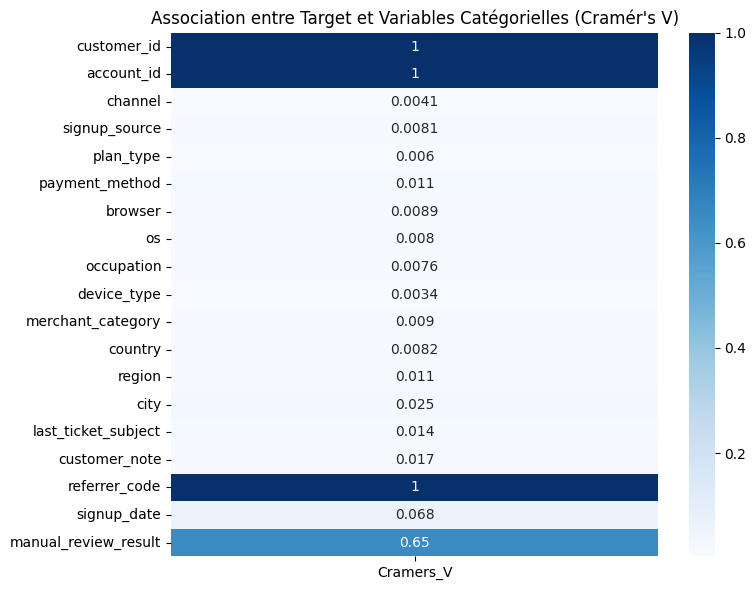

In [40]:
def cramers_v(x, y):
    contingency_table = pd.crosstab(x, y)
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    r, k = contingency_table.shape
    return np.sqrt(chi2 / (n * (min(k-1, r-1))))

cat_cols = df.select_dtypes(include=['object', 'category']).columns

results = {}

for col in cat_cols:
    results[col] = cramers_v(df[col], df['target_is_fraud'])

heatmap_df = pd.DataFrame.from_dict(results, orient='index', columns=['Cramers_V'])

plt.figure(figsize=(8,6))
sns.heatmap(heatmap_df, annot=True, cmap="Blues")
plt.title("Association entre Target et Variables Catégorielles (Cramér's V)")
plt.tight_layout()
plt.show()


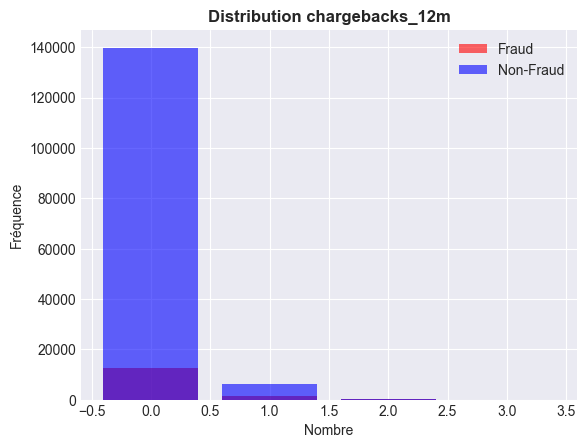

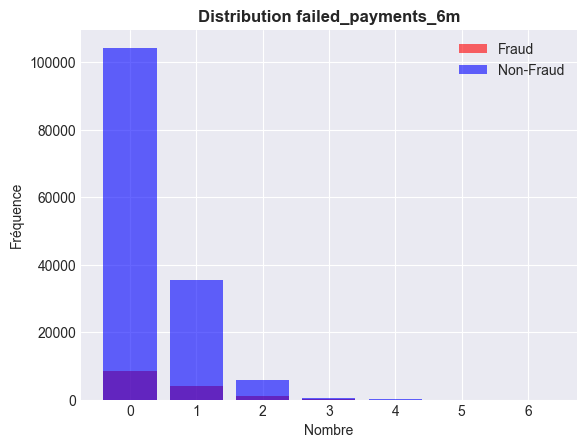

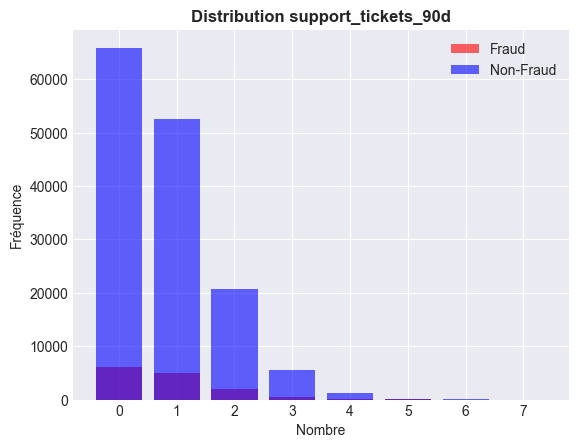

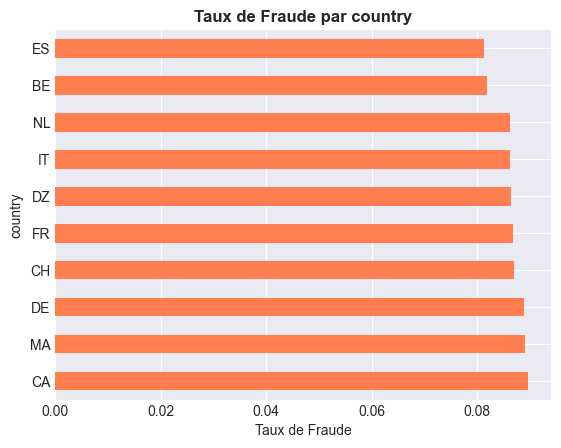

<Figure size 640x480 with 0 Axes>

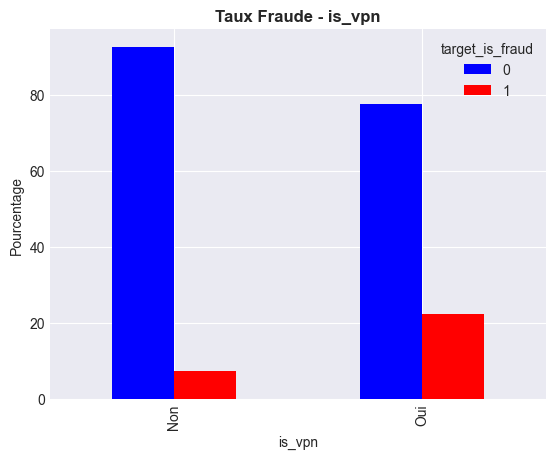

<Figure size 640x480 with 0 Axes>

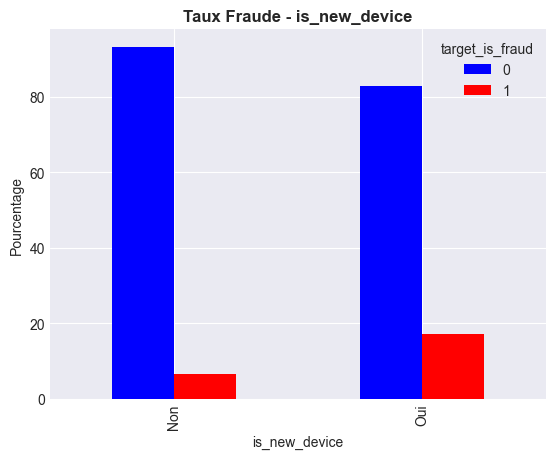

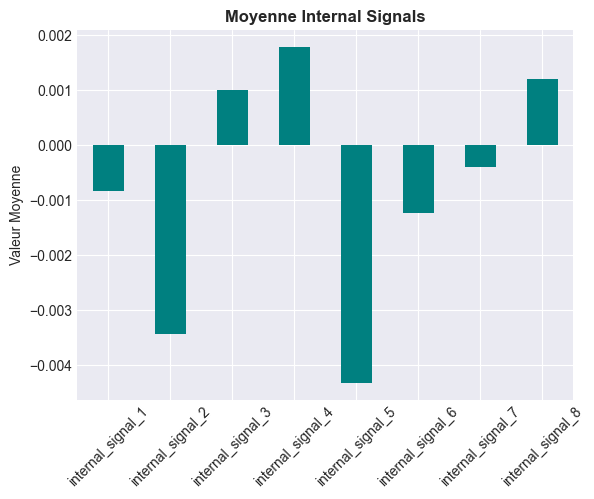

In [10]:

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

DATA_FILE = '../data/kaggle_b2_fraud_train_v4.csv'
df = pd.read_csv(DATA_FILE)

critical_features = ['chargebacks_12m', 'failed_payments_6m', 'support_tickets_90d']
for col in critical_features:
    if col in df.columns:
        fig = plt.figure()
        fraud_vals = df[df['target_is_fraud']==1][col].value_counts().sort_index()
        nonfraud_vals = df[df['target_is_fraud']==0][col].value_counts().sort_index()
        x = range(max(len(fraud_vals), len(nonfraud_vals)))
        plt.bar(x, fraud_vals.reindex(x, fill_value=0), alpha=0.6, label='Fraud', color='red')
        plt.bar(x, nonfraud_vals.reindex(x, fill_value=0), alpha=0.6, label='Non-Fraud', color='blue')
        plt.title(f'Distribution {col}', fontweight='bold')
        plt.xlabel('Nombre')
        plt.ylabel('Fréquence')
        plt.legend()
        plt.show()


categorical_features = ['channel', 'payment_method', 'device_type', 'browser', 'country']
for col in categorical_features:
    if col in df.columns:
        fig = plt.figure()
        group = df.groupby(col)['target_is_fraud'].agg(['mean','count'])
        group = group[group['count']>50].sort_values('mean', ascending=False)
        if col in ['country','browser']:
            group = group.head(10)
        group['mean'].plot(kind='barh', color='coral')
        plt.title(f'Taux de Fraude par {col}', fontweight='bold')
        plt.xlabel('Taux de Fraude')
        plt.ylabel(col)
        plt.show()


tech_features = ['is_vpn', 'is_new_device']
for col in tech_features:
    if col in df.columns:
        fig = plt.figure()
        ctab = pd.crosstab(df[col], df['target_is_fraud'], normalize='index')*100
        ctab.plot(kind='bar', color=['blue','red'])
        plt.title(f'Taux Fraude - {col}', fontweight='bold')
        plt.xticks([0,1], ['Non','Oui'])
        plt.ylabel('Pourcentage')
        plt.show()


internal_signals = [c for c in df.columns if c.startswith('internal_signal_')]
if internal_signals:
    fig = plt.figure()
    df[internal_signals].mean().plot(kind='bar', color='teal')
    plt.title('Moyenne Internal Signals', fontweight='bold')
    plt.xticks(rotation=45)
    plt.ylabel('Valeur Moyenne')
    plt.show()